In [1]:
import numpy as np
import glob
import os
import matplotlib.pyplot as plt
import sys
import h5py

sys.path.append("../src/")
from mrvis.utils.matplotlib_style import gcolor

filepath = "/home/max/Repos/Magnetic-Reconnection-Visualization/data/reconnection_rates_solar_wind"

all_files = sorted(glob.glob(os.path.join(filepath, "reconnection_rates_step_*.txt")))
number_of_files = len(all_files)

print("Found {} files".format(number_of_files))

Found 109 files


Found 109 files


Text(0.5, 1.0, 'Reconnection Rate Histogram Over Time Steps')

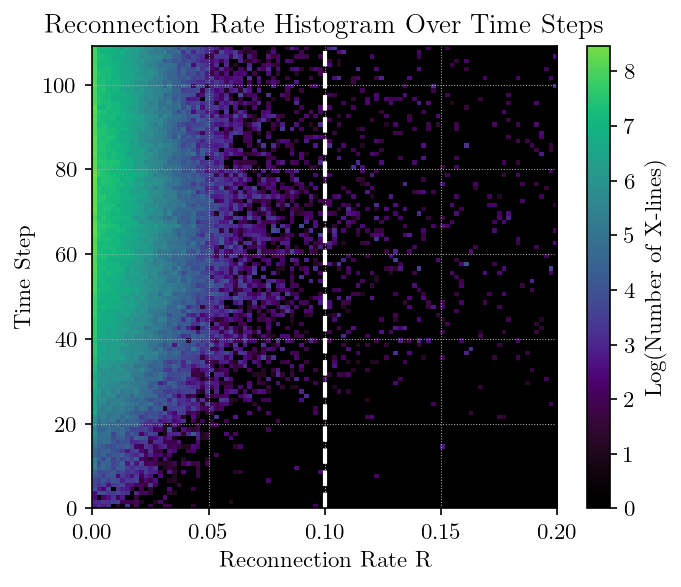

In [ ]:
gradient = ["black", "orange", "green"]

filepath = "/home/max/Repos/Magnetic-Reconnection-Visualization/data/reconnection_rates_solar_wind"
# filepath = "/home/max/Repos/Magnetic-Reconnection-Visualization/data/reconnection_rates_quasiXlines"


all_files = sorted(glob.glob(os.path.join(filepath, "reconnection_rates_step_*.txt")))
number_of_files = len(all_files)

print("Found {} files".format(number_of_files))


def plot_histogram(step, datapath, max_reconnection_rate=0.2, bins=30):
    data = np.loadtxt(datapath)
    if len(data) == 0:
        print(f"Warning: No data found in {datapath}. Skipping.")
        return 0.0, np.array([])
    bins = np.linspace(0.0, max_reconnection_rate, bins)
    x, bins = np.histogram(data, bins=bins, density=False)
    return x


bins = 100
max_reconnection_rate = 0.2

plt.figure(figsize=(5, 4), dpi=150)

all_histograms = []
for i, datapath in enumerate(all_files):
    # print(f"Processing {datapath}")
    data = plot_histogram(i, datapath, max_reconnection_rate=max_reconnection_rate, bins=bins)
    all_histograms.append(data)

plt.imshow(
    np.log(np.array(all_histograms) + 1),
    origin="lower",
    aspect="auto",
    cmap="cmr.lavender",
    interpolation="nearest",
    extent=[0, max_reconnection_rate, 0, number_of_files],
)
plt.colorbar(label="Log(Number of QXLs)")
plt.vlines(0.1, 0, number_of_files, color="white", linestyle="--", linewidth=2.0, label="Threshold R=0.1")
plt.ylabel("Time Step")
plt.xlabel("Reconnection Rate R")
# plt.legend()
plt.title("Reconnection Rate Histogram Over Time Steps")

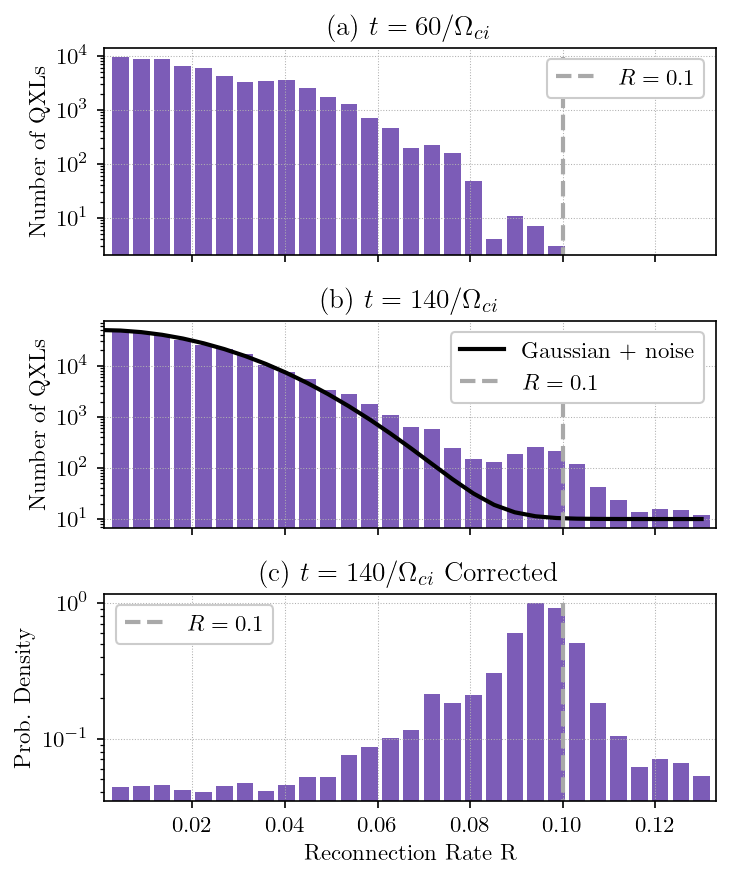

In [12]:
from scipy.optimize import curve_fit


def expo(x, a, b):
    return a * np.exp(-b * x**2) + 10


# Global plot config
n_bins = 30
max_reconnection_rate = 0.13
bins = np.linspace(0.0, max_reconnection_rate, n_bins)

# Create subplot figure
fig, axs = plt.subplots(3, 1, figsize=(5, 6), dpi=150, sharex=True)

# -----------------------
# 1. Second Histogram (quasi-Xlines)
datapath2 = "/home/max/Repos/Magnetic-Reconnection-Visualization/data/reconnection_rates_quasiXlines/reconnection_rates_step_0034.txt"
data2 = np.loadtxt(datapath2)
x2, _ = np.histogram(data2, bins=bins, density=False)

axs[0].hist(data2, bins=bins, density=False, color=gcolor("violet"), rwidth=0.8, align="right")
axs[0].vlines(0.1, 0.0, np.max(x2), color="darkgray", linestyle="--", linewidth=2.0, label="$R=0.1$")
axs[0].set_yscale("log")
axs[0].set_ylabel("Number of QXLs")
axs[0].legend(framealpha=1.0, handlelength=1.9)
axs[0].grid(True)
axs[0].set_title(r"(a) $t=60/\Omega_{ci}$")
axs[0].set_xlim(bins[1], 0.133)


# -----------------------
# 2. Original Histogram + Fit
datapath1 = "/home/max/Repos/Magnetic-Reconnection-Visualization/data/reconnection_rates_3.txt"
data1 = np.loadtxt(datapath1)
x1, _ = np.histogram(data1, bins=bins, density=False)

xfit = bins[1:20]
yfit = x1[:19]
popt, _ = curve_fit(expo, xfit, yfit, p0=(1.0, 1.0), maxfev=10000)

axs[1].hist(data1, bins=bins, density=False, color=gcolor("violet"), rwidth=0.8, align="right")
axs[1].plot(bins, expo(bins, *popt), linewidth=2.0, color="black", label="Gaussian + noise")
axs[1].vlines(0.1, 0.0, np.max(x1), color="darkgray", linestyle="--", linewidth=2.0, label="$R=0.1$")
axs[1].set_yscale("log")
axs[1].set_ylabel("Number of QXLs")
axs[1].legend(framealpha=1.0, handlelength=1.9)
axs[1].grid(True)
axs[1].set_title(r"(b) $t=140/\Omega_{ci}$")
axs[1].set_xlim(0.001, 0.133)


# -----------------------
# 3. Corrected + Normalized Histogram
x_norm = x1 / expo(bins[1:], *popt)
x_norm /= np.max(x_norm)

axs[2].bar(bins[1:], x_norm, width=np.diff(bins) * 0.8, align="center", color=gcolor("violet"))
axs[2].vlines(0.1, 0.0, np.max(x_norm), color="darkgray", linestyle="--", linewidth=2.0, label="$R=0.1$")
axs[2].set_yscale("log")
axs[2].set_ylabel("Prob. Density")
axs[2].legend(framealpha=1.0, handlelength=1.9)
axs[2].set_xlabel("Reconnection Rate R")
axs[2].set_title(r"(c) $t=140/\Omega_{ci}$ Corrected")
axs[2].grid(True)
axs[2].set_xlim(0.001, 0.133)


# -----------------------
# Final layout
plt.tight_layout()
plt.savefig("reconnection_rate_subplots.png", bbox_inches="tight", dpi=300)
plt.show()

<Figure size 600x450 with 0 Axes>

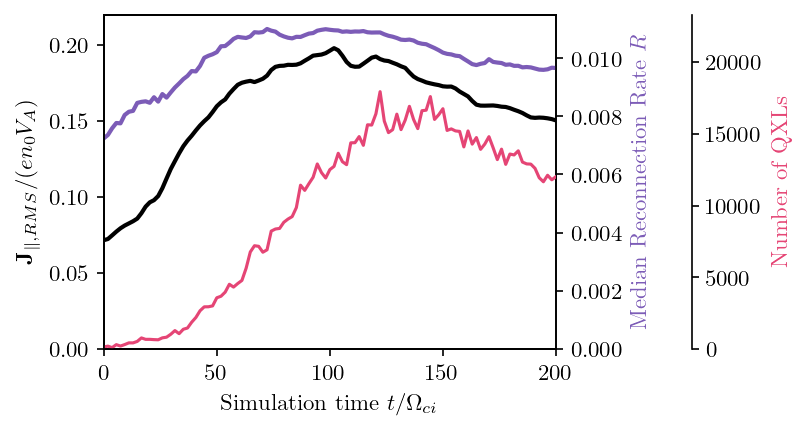

In [17]:
current_density = np.loadtxt("/home/max/Repos/Magnetic-Reconnection-Visualization/data/solar_wind_current_density.dat")


def exponential_moving_average(x, alpha=0.1):
    ema = [x[0]]
    for i in range(1, len(x)):
        ema.append(alpha * x[i] + (1 - alpha) * ema[-1])
    return np.array(ema)


def get_max_reconnection(datapath):
    data = np.loadtxt(datapath)
    n = len(data)
    if n == 0:
        return 0.0, 0
    data = np.copy(data[np.where(data > 0.0)])
    data = np.copy(data[np.where(data < 1.0)])
    max_r = np.median(data)

    return max_r, len(data)


plt.figure(figsize=(4, 3), dpi=150)

max_reconnection_rates = []
number_of_lines = []
time_steps = []
for i, datapath in enumerate(all_files):
    max_r, n = get_max_reconnection(datapath)
    max_reconnection_rates.append(max_r)
    number_of_lines.append(n)
    time_steps.append(i)

fig, ax1 = plt.subplots(figsize=(6, 3), dpi=150)

ax1.set_xlim(0, 200)

ax2 = ax1.twinx()
ax3 = ax1.twinx()

ax3.spines.right.set_position(("axes", 1.3))

xlin = np.linspace(0, 200, len(max_reconnection_rates))

ax3.plot(xlin, number_of_lines, color="#e54575", linewidth=1.5)
ax3.set_ylabel("Number of QXLs", color="#e54575")
ax3.grid(False)
ax3.set_ylim(0, np.max(number_of_lines) * 1.3)

ax1.plot(xlin, current_density[:, 1], color="black", linewidth=2)
ax1.set_ylim(0, 0.22)
ax1.set_xlabel(r"Simulation time $t/\Omega_{ci}$")
ax1.set_ylabel(r"$\mathbf{J}_{\|,RMS}/(e n_0 V_A)$", color="black")
ax1.grid(False)

# ax2.plot(xlin, max_reconnection_rates, color=gcolor("violet"), linewidth=1.5, alpha=0.5, label="Reconnection Rate $R$")
ax2.set_ylabel("Median Reconnection Rate $R$", color=gcolor("violet"))
ax2.grid(False)
ax2.set_ylim(0.00, 0.0115)

ax2.plot(
    xlin,
    exponential_moving_average(max_reconnection_rates, alpha=0.1),
    color=gcolor("violet"),
    linestyle="-",
    linewidth=2,
    label="EMA Reconnection Rate $R$",
)


plt.tight_layout()
plt.savefig("num_points_lines.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

In [5]:
print(np.corrcoef(current_density[:, 1], exponential_moving_average(max_reconnection_rates, alpha=0.1))[0, 1])

0.977988795661522


In [6]:
print(np.corrcoef(current_density[:, 1], number_of_lines)[0, 1])

0.747609637274827


In [7]:
print(np.corrcoef(current_density[:, 1], max_reconnection_rates)[0, 1])

0.5506093093328387


Timestep_33000
<KeysViewHDF5 ['B', 'E']>


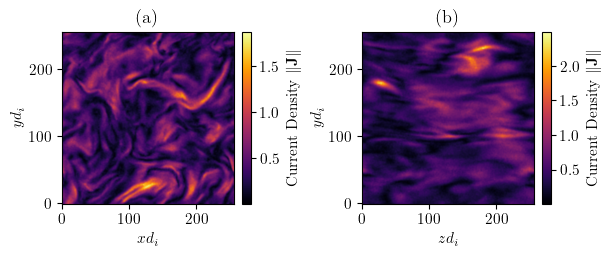

In [8]:
path = "/run/media/max/Data/Simulations/Plasma/hybrid_3d_turbulence/dings.h5"

step = 70


def get_ordered_list_of_times(timesteps):
    """Get ordered list of time steps from dings.h5

    Parameters
    ----------
    timesteps : List
        List of timesteps of type string

    Returns
    -------
    np.array
        Sorted list of timestep strings
    """
    times = np.zeros(len(timesteps), dtype="int")
    for i, step in enumerate(timesteps):
        if "Timestep" not in step:
            continue
        times[i] = int(step.split("Timestep_")[-1])
    return np.sort(times)



with h5py.File(path, "r") as f:
    timestep = f"Timestep_{get_ordered_list_of_times(list(f.keys()))[step]}"

    print(timestep)
    print(f[timestep]["felder"].keys())

    current_density = np.array(
        [
            np.array(f[timestep]["rho"]["rhoI[1]"]),
            np.array(f[timestep]["rho"]["rhoI[2]"]),
            np.array(f[timestep]["rho"]["rhoI[3]"]),
        ]
    )
    abs_J = np.sqrt(np.sum(current_density**2, axis=0))
    
    magnetic_field = np.array(
        [
            np.array(f[timestep]["felder"]["B"]["B[0]"]),
            np.array(f[timestep]["felder"]["B"]["B[1]"]),
            np.array(f[timestep]["felder"]["B"]["B[2]"]),
        ]
    )
    
    fig, ax = plt.subplots(1,2, figsize=(6,3),layout="compressed")
    
    slice_idx = 0
    cmap = "inferno"

    im = ax[0].imshow(abs_J[:, :, slice_idx].T, origin="lower", cmap=cmap, interpolation="bicubic", aspect="equal")
    ax[0].set_title("(a)")
    ax[0].set_ylabel("$y d_i$")
    ax[0].set_xlabel("$x d_i$")
    ax[0].grid(False)
    plt.colorbar(im, ax=ax[0], label=r"Current Density $\|\mathbf{J}\|$")

    im2 = ax[1].imshow(abs_J[slice_idx,:,:], origin="lower", cmap=cmap, interpolation="bicubic", aspect="equal")
    ax[1].set_title("(b)")
    ax[1].set_xlabel("$z d_i$")
    ax[1].set_ylabel("$y d_i$")
    ax[1].grid(False)
    plt.colorbar(im2, ax=ax[1], label=r"Current Density $\|\mathbf{J}\|$")
    
    # plt.tight_layout()
    plt.savefig("solar_wind_current_density.png", dpi=300, bbox_inches='tight', pad_inches=0)